# Making the dataset and training the model

This file contains the code to make the dataset from depth tensor and the embeddings retrieved from the same tensors. But also one thing to keep track is 
error value of -1 for places where no depth values could be retriebed. They need to be filtered out and left out of the final training data. 

In [9]:
import argparse
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

In [10]:
from utils import getDevice

In [11]:
class EmbedDepthDataset(Dataset):
    """
    This class matched the YOLO embeddings from a file to depth retrieved
    for the same images and creates a dataset from them, that can be used to 
    train the final model.

    Args:
        embed_path: path to .pt embeddings (N,256)
        depths_path: path to .pt (N,)
    """

    def __init__(self, embed_path: str, depths_path: str):
        #opening the files
        embeds = torch.load(embed_path, weights_only=True).float()
        depths = torch.load(depths_path, weights_only=True).float()

        #filtering depths to only allow valid ones
        print(f"Removing {(depths==-1).sum()} invalid depths")
        mask = depths != -1
        embeds_masked = embeds[mask]
        depths_masked = depths[mask]   

        #saving results
        self.depths = depths_masked
        self.embeddings = embeds_masked

        assert len(self.embeddings)==len(self.depths), (
            f"The embeddings array is not the same length as the depths"
            f"EMBEDDINGS: {len(self.embeddings)}\nDEPTHS: {len(self.depths)}"
        )

    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.depths[idx]

In [12]:
class DistanceRegressor(nn.Module):
    """
    Model to predict based on YOLO embeddings the distance to a car. It takes in (256) embedding and 
    outputs a single distance value in meters.

    Architecture is similar to the paper:
    1. Linear(256,128) + ReLU
    2. Linear(128,64) + ReLU
    3. Linear(64,1) + Softplus (to ensure positive output)
    """

    def __init__(self, input_size: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 2048),
            nn.ReLU(),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, 1),
            nn.Softplus()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [13]:
EMBED_PATH = "../data/embeds_preds.pt"
DEPTHS_PATH = "../data/ransac_depth.pt"

dataset = EmbedDepthDataset(EMBED_PATH, DEPTHS_PATH)

Removing 4 invalid depths


In [14]:
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss
model = DistanceRegressor()

# Create the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, eps=1.0)

epochs = 500

In [15]:
losses = np.array([])


for epoch in range(epochs):
    avg_loss = np.array([])
    for embeds, depths in DataLoader(dataset, batch_size=32, shuffle=True):
        # Forward pass
        preds = model(embeds)
        loss = loss_fn(preds.squeeze(), depths)
        
        avg_loss = np.append(avg_loss,loss.item())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    losses = np.append(losses, avg_loss.mean())
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {losses[epoch]:.4f}")

Epoch 0/500, Loss: 17.5677
Epoch 10/500, Loss: 8.1466
Epoch 20/500, Loss: 7.5780
Epoch 30/500, Loss: 6.6358
Epoch 40/500, Loss: 5.5747
Epoch 50/500, Loss: 5.0278
Epoch 60/500, Loss: 4.8024
Epoch 70/500, Loss: 4.6430
Epoch 80/500, Loss: 4.4136
Epoch 90/500, Loss: 4.3576
Epoch 100/500, Loss: 4.1518
Epoch 110/500, Loss: 4.0409
Epoch 120/500, Loss: 3.9311
Epoch 130/500, Loss: 3.8178
Epoch 140/500, Loss: 3.7538
Epoch 150/500, Loss: 3.6803
Epoch 160/500, Loss: 3.6265
Epoch 170/500, Loss: 3.6431
Epoch 180/500, Loss: 3.5300
Epoch 190/500, Loss: 3.4634
Epoch 200/500, Loss: 3.4746
Epoch 210/500, Loss: 3.4534
Epoch 220/500, Loss: 3.4598
Epoch 230/500, Loss: 3.3261
Epoch 240/500, Loss: 3.4495
Epoch 250/500, Loss: 3.3169
Epoch 260/500, Loss: 3.2573
Epoch 270/500, Loss: 3.2176
Epoch 280/500, Loss: 3.2113
Epoch 290/500, Loss: 3.2777
Epoch 300/500, Loss: 3.1871
Epoch 310/500, Loss: 3.1326
Epoch 320/500, Loss: 3.0563
Epoch 330/500, Loss: 3.0976
Epoch 340/500, Loss: 2.9982
Epoch 350/500, Loss: 2.9540
Ep

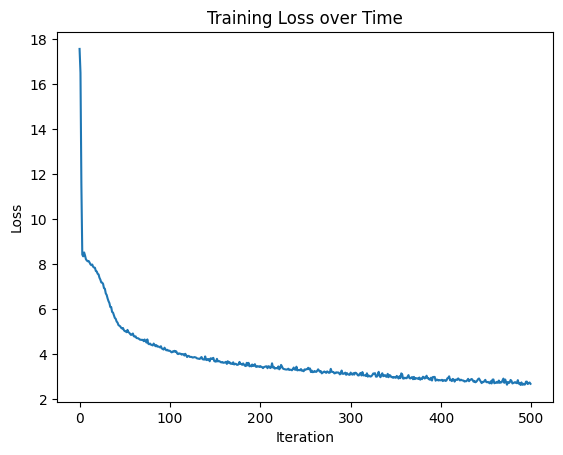

In [16]:
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.show()